## Identificación de Operadores Ineficaces en CallMeMaybe

### Objetivos del Estudio

El propósito de este análisis es diseñar e implementar un modelo de diagnóstico operativo para la plataforma de telefonía virtual CallMeMaybe.
El fin es identificar de forma precisa a aquellos operadores que presentan un rendimiento deficiente bajo tres frentes de negocio:
1. **Llamadas entrantes perdidas.** Alta tasa de abandono por parte de los clientes.
2. **Tiempos de espera prolongados.** Cuellos de botella en la atención telefónica entrante.
3. **Bajo volumen de llamadas salientes**


### Configuración del Entorno y Carga de Datos

Prepararemos el entorno de trabajo, importando las librerías para la manipulación estadística (pandas, numpy), de visualización (matplotlib, seaborn) y prueba estadística (scipy); para posterior cargar los datasets.

In [76]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo visual estándar para reportes
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [77]:
# Carga de datos con control de excepciones

try:
    df_telecom = pd.read_csv('data/telecom_dataset_new.csv')
    df_clients = pd.read_csv('data/telecom_clients.csv')
    print('¡Éxito! Ambos conjuntos de datos se cargaron correctamente en VS Code.')
except FileNotFoundError as e:
    print(f'Error: No se encontró algún archivo de datos. Verifica la ruta.\nDetalles: {e}')


¡Éxito! Ambos conjuntos de datos se cargaron correctamente en VS Code.


### Análisis Exploratorio de Datos

Diganosticaremos la estructura técnica de las columnas, validaremos si existen valores nulos y en caso de ser así tratarlos (especialmente en la columna **operator_id**), revisaremos duplicados y si lo hay, eliminarlos.
No sercioraremos que las columnas de fecha se encuentren con el tipo correcto.

In [78]:
# Validar la dimensión de los datasets con shape
print(f'\nDimensiones de Telecom: {df_telecom.shape[0]} filas, {df_telecom.shape[1]} columnas')
print(f'Dimensiones de Clientes: {df_clients.shape[0]} filas, {df_clients.shape[1]} columnas')

# Visualización general de los datasets
print('\n--- INFORMACIÓN TÉCNICA DE CLIENTES ---')
df_clients.info()


Dimensiones de Telecom: 53902 filas, 9 columnas
Dimensiones de Clientes: 732 filas, 3 columnas

--- INFORMACIÓN TÉCNICA DE CLIENTES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [79]:
# Inspección de tipo de datos y nulos en el dataset de Telecomunicaciones
print('\n--- INFORMACIÓN TÉCNICA DE TELECOM ---')
df_telecom.info()

# Conteo de valores nulos por columna
print('\n--- VALORES NULOS EN TELECOM ---')
print(df_telecom.isnull().sum())


--- INFORMACIÓN TÉCNICA DE TELECOM ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB

--- VALORES NULOS EN TELECOM ---
user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
c

In [80]:
# Vista previa de los primeros registros de llamadas
print('\n--- VISTA PREVIA DE TELECOM ---')
print(df_telecom.head())


--- VISTA PREVIA DE TELECOM ---
   user_id                       date direction internal  operator_id  \
0   166377  2019-08-04 00:00:00+03:00        in    False          NaN   
1   166377  2019-08-05 00:00:00+03:00       out     True     880022.0   
2   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
3   166377  2019-08-05 00:00:00+03:00       out     True     880020.0   
4   166377  2019-08-05 00:00:00+03:00       out    False     880022.0   

   is_missed_call  calls_count  call_duration  total_call_duration  
0            True            2              0                    4  
1            True            3              0                    5  
2            True            1              0                    1  
3           False            1             10                   18  
4            True            3              0                   25  


**Observaciones:**
Contamos con los siguientes datos:
* 53,902 entrada de datos en el dataset Telecom
* 732 entrada de datos en Clientes
* Valores nulos en las columnas internal (117) y operator_id (8172). 
* Tipo de datos en texto (object) en las columnas de fecha (date_start y date)

**Acciones:**
- Rellenar los valores nulos en internal con el valor más frecuente (la moda) dado que son pocos registros.
- La columna operator_id es clave para identificar que operadores son ineficaces por lo que tener valores nulos/ausentes no es funcional para evaluar el rendimiento, por tanto se eliminaran filas con valores nulos; lo que representa un 15% de los datos.
* Convertir a to_datetime las columnas 'date' y 'date_start'. 

In [81]:
# Conversión de tipo de datos a datetime
df_telecom['date'] = pd.to_datetime(df_telecom['date'])
df_clients['date_start'] = pd.to_datetime(df_clients['date_start'])

# Eliminar valores ausentes en operator_id
df_telecom = df_telecom.dropna(subset=('operator_id'))

# Tratamiento de nulos en la columna 'internal' (llenar con la moda)
moda_internal = df_telecom['internal'].mode()[0]
df_telecom['internal'] = df_telecom['internal'].fillna(moda_internal)

# Verificar que ya no existan valores nulos en df_telecom
print('--- CONTEO DE NULOS POST-LIMPIEZA')
print(df_telecom.isnull().sum())
print('\n--- NUEVOS TIPOS DE DATOS ---')
print('Columna "date":', df_telecom['date'].dtypes)
print('Columna "date_start:"', df_clients['date_start'].dtype)

--- CONTEO DE NULOS POST-LIMPIEZA
user_id                0
date                   0
direction              0
internal               0
operator_id            0
is_missed_call         0
calls_count            0
call_duration          0
total_call_duration    0
dtype: int64

--- NUEVOS TIPOS DE DATOS ---
Columna "date": datetime64[ns, UTC+03:00]
Columna "date_start:" datetime64[ns]


C:\Users\Usuario\AppData\Local\Temp\ipykernel_17000\588830531.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_telecom['internal'] = df_telecom['internal'].fillna(moda_internal)


In [82]:
# Detectar y eliminar registros duplicados
duplicados = df_telecom.duplicated().sum()
print(f"\nCantidad de filas duplicadas detectadas: {duplicados}")
if duplicados > 0:
    df_telecom = df_telecom.drop_duplicates()
    print('Registros duplicados eliminados con éxito.')


Cantidad de filas duplicadas detectadas: 4184
Registros duplicados eliminados con éxito.


### Definición de Umbrales Operativos

Para evaluar la ineficacia bajo los criterios solicitados por el negocio realizaremos lo siguiente:
* Calcularemos el tiempo de espera neto por llamada (`waiting_time`). 
* Agruparemos el historial por cada operador único para consolidar su perfil operativo (tasas de abandono, promedios de espera y llamadas salientes realizadas).
* Analizaremos estadísticamente los percentiles de la empresa para fijar los límites numéricos de ineficacia.


In [83]:
# Calcular el tiempo de espera en segundos
df_telecom['waiting_time'] = df_telecom['total_call_duration'] - df_telecom['call_duration']

# Vista previa para asegurar que el cálculo sea correcto 
df_telecom[['call_duration', 'total_call_duration', 'waiting_time']].head()


,call_duration,total_call_duration,waiting_time
1,0,5,5
2,0,1,1
3,10,18,8
4,0,25,25
5,3,29,26


In [84]:
# Resúmen estadístico descriptivo crudo de los tiempos y recuentos de llamadas
print('\n--- RESUMEN ESTADÍSTICO DE LAS MÉTRICAS ---')
display(df_telecom[['calls_count', 'call_duration', 'waiting_time']].describe())


--- RESUMEN ESTADÍSTICO DE LAS MÉTRICAS ---


,calls_count,call_duration,waiting_time
count,41546.000000,41546.000000,41546.000000
mean,16.900424,1009.769172,311.823641
std,59.749373,4064.106117,1175.373073
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,19.000000
50%,4.000000,106.000000,60.000000
75%,13.000000,770.000000,219.000000
max,4817.000000,144395.000000,46474.000000


**Observaciones:**

* El percentil 25 muestra una duración de llamada (`call_duration`) de 0.0 segundos, pero registra un tiempo de espera activo. Esto confirma de forma preliminar que existe un volumen masivo de interacciones donde los clientes colgaron antes de ser atendidos por un operador.
* La mediana del tiempo de espera (50%) es de apenas 60 segundos, mientras que el promedio se eleva a 311.8 segundos debido a valores máximos de hasta 46,474 segundos. 

Esto podría indicar que la ineficacia o lentitud extrema está concentrada en casos específicos que sesgan negativamente la métrica global del servicio.


In [85]:
# Agrupar datos para obtener métricas clave por operador

operadores_metrics = df_telecom.groupby('operator_id').agg(
    total_llamadas=('calls_count', 'sum'),

    # Métricas Entrantes (Inbound)
    llamadas_entrantes=('calls_count', lambda x: x[df_telecom.loc[x.index, 'direction'] == 'in'].sum()),
    entrantes_perdidas=('calls_count', lambda x: x[(df_telecom.loc[x.index, 'direction'] == 'in') & (df_telecom.loc[x.index, 'is_missed_call'] == True)].sum()),
    espera_total_entrantes=('waiting_time', lambda x: x[df_telecom.loc[x.index, 'direction'] == 'in'].sum()),

    # Métricas Salientes (Outbound)
    llamadas_salientes=('calls_count', lambda x: x[df_telecom.loc[x.index, 'direction'] == 'out'].sum())
).reset_index()

# Calcular tasas porcentuales y promedios para estandarizar la comparación
operadores_metrics['tasa_perdidas_in'] = (operadores_metrics['entrantes_perdidas'] / operadores_metrics['llamadas_entrantes']).fillna(0)
operadores_metrics['espera_promedio_in'] = (operadores_metrics['espera_total_entrantes'] / operadores_metrics['llamadas_entrantes']).fillna(0)

# Vista previa del perfil de los operadores
print('--- PERFIL OPERATIVO POR OPERADOR ---')
display(operadores_metrics.head())

# Análisis descriptivo del equipo agrupado de umbrales
print('\n--- CONFIGURACIÓN DE UMBRALES DE REFERENCIA ---')
display(operadores_metrics[['tasa_perdidas_in', 'espera_promedio_in', 'llamadas_salientes']].describe())

--- PERFIL OPERATIVO POR OPERADOR ---


,operator_id,total_llamadas,llamadas_entrantes,entrantes_perdidas,espera_total_entrantes,llamadas_salientes,tasa_perdidas_in,espera_promedio_in
0,879896.0,930,58,0,574,872,0.0,9.896552
1,879898.0,7313,104,0,1680,7209,0.0,16.153846
2,880020.0,45,7,0,54,38,0.0,7.714286
3,880022.0,197,8,0,112,189,0.0,14.000000
4,880026.0,2232,24,0,143,2208,0.0,5.958333



--- CONFIGURACIÓN DE UMBRALES DE REFERENCIA ---


,tasa_perdidas_in,espera_promedio_in,llamadas_salientes
count,1092.000000,1092.000000,1092.000000
mean,0.012134,12.077541,557.090659
std,0.054875,12.950121,2819.492227
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,2.000000
50%,0.000000,10.076923,33.000000
75%,0.000000,17.562976,355.250000
max,1.000000,115.500000,58977.000000


**Observaciones:**

Con base en los resultados establecer los siguientes umbrales:

* Para Llamadas Perdidas tenemos que más del 75% del equipo mantiene una tasa de abandono perfecta de 0.0. Por lo tanto, se estableceremos el promedio global de **0.012134** como el límite de tolerancia técnica; cualquier operador que pierda un porcentaje mayor de llamadas entrantes entraría en estado de alerta.
* Para Llamadas en espera entrantes seleccionaremos el percentil 75 de **17.562976**. 
Un operador que haga esperar a los clientes entrantes por encima de esta barrera se considera ineficaz por bajo rendimiento en velocidad de atención.
* Llamadas inactivas salientes. Al observar que el percentil 25 de los operadores activos realiza un volumen mínimo de llamadas (2), se establece un umbral de corte estricto de menos de 5 llamadas salientes totales.


### Segmentación y Clasificacion del Rendimiento por Operador

Con base en las métricas consolidadas de la fase anterior y los criterios de negocio, se diseñará una función para clasificar a cada operador en una de dos categorías: "Eficaz" o "Ineficaz". Un operador será etiquetado como ineficaz si su tasa de llamadas perdidas supera la media global, si su tiempo de espera supera el percentil 75 operativo de la compañía, o si muestra inactividad comercial en llamadas salientes. Al final, se medirá el volumen y peso porcentual de cada grupo.



Consideraremos ineficaz a un operadore si cumple al menos uno de los siguientes criterios negativos:
* Su tasa de llamadas perdidas es mayor al promedio global (>0.012134)
* Su tiempo de espera promedio supera el percentil 75 (>17.562976 segundos)
* Hace llamadas salientes, pero su volumen es extremadamente bajo ( menor al percentil 25 de los activos, por ejemplo < 5 llamadas)

In [86]:
# Definir umbrales basados en el resultado estadístico
UMBRAL_TASA_PERDIDAS = 0.012134
UMBRAL_ESPERA_PROMEDIO = 17.562976
UMBRAL_SALIENTES_BAJO = 5.0

In [87]:
# Funcion para aplicar los criterios a cada operador
def evaluar_ineficacia(row):
    # Criterio 1: Alta tasa de llamadas perdidas entrantes
    alta_tasa_perdidas = row['tasa_perdidas_in'] > UMBRAL_TASA_PERDIDAS
    
    # Criterio 2: Tiempo de espera muy largo
    espera_prolongada = row['espera_promedio_in'] > UMBRAL_ESPERA_PROMEDIO

    # Criterio 3: Pocas llamadas salientes (sólo si realiza actividad saliente)
    pocas_salientes = (row['llamadas_salientes'] > 0) & (row['llamadas_salientes'] < UMBRAL_SALIENTES_BAJO)

    # Si cumple cualquiera de los tres criterios negativos, es Ineficaz
    if alta_tasa_perdidas or espera_prolongada or pocas_salientes:
        return 'Ineficaz'
    else:
        return 'Eficaz'

In [88]:
# Aplicar la clasificación al DataFrame
operadores_metrics['desempeno'] = operadores_metrics.apply(evaluar_ineficacia, axis=1)

print('--- CONTEO DE OPERADORES POR DESEMPEÑO ---')
print(operadores_metrics['desempeno'].value_counts())

porcentaje_ineficaces = (operadores_metrics['desempeno'].value_counts(normalize=True)*100)
print('\n--- PORCENTAJE DE OPERADORES ---')
print(porcentaje_ineficaces)

--- CONTEO DE OPERADORES POR DESEMPEÑO ---
desempeno
Eficaz      627
Ineficaz    465
Name: count, dtype: int64

--- PORCENTAJE DE OPERADORES ---
desempeno
Eficaz      57.417582
Ineficaz    42.582418
Name: proportion, dtype: float64


Los resultados nos muestran que 465 operadores son Ineficaces siendo un 42.58% del total, frente a 627 operadores Eficaces representando un 57.41% del total.

### Prueba de Hipótesis Estadística

Para asegurar que la segmentación realizada describe un comportamiento real y no un patrón aleatorio, se procederá a realizar una validación científica de los datos utilizando inferencia estadística.

* **Prueba 1.** Mediante la prueba no paramétrica de Mann-Whitney U, se evaluará si la diferencia observada en los tiempos de espera entre operadores eficaces e ineficaces es real y estadísticamente significativa.

* **Prueba 2.** Mediante una prueba de Chi-cuadrado de independencia, se validará si la ineficacia operativa se distribuye de manera homogénea o si se encuentra directamente vinculada con el plan tarifario contratado por la organización cliente.

### Definición de Hipótesis 1

**Hipótesis 1:** Tiempo de espera promedio difiere entre operadores eficaces e ineficaces.

* **Hipótesis Nula (H0):**
El tiempo de espera promedio de las llamadas entrantes es idéntico entre los operadores eficaces y los ineficaces.

* **Hipótesis Alternativa (H1):**
El tiempo de espera promedio de las llamadas entrantes es significativamente diferente entre ambos grupos.

In [89]:
from scipy import stats

# Separar los tiempos de espera promedio según el grupo de desempeño
espera_eficaces = operadores_metrics[operadores_metrics['desempeno'] == 'Eficaz']['espera_promedio_in']
espera_ineficaces = operadores_metrics[operadores_metrics['desempeno'] == 'Ineficaz']['espera_promedio_in']

# Aplicar la prueba estadística (Mann-Whitney U por el sesgo en la distribución)
stat, p_value = stats.mannwhitneyu(espera_eficaces, espera_ineficaces, alternative='two-sided')

print('--- PRUEBA DE HIPÓTESIS 1 (TIEMPOS DE ESPERA) ---')
print(f'Estadístico de prueba: {stat:.4f}')
print(f'Valor p(p-value): {p_value}')

# Interpretación formal (alpha = 0.05)
alpha = 0.05
if p_value < alpha:
    print('Rechazamos la hipótesis nula')
    print('Conclusión: Existe una diferencia estadísticamente significativa en el tiempo de espera entre operadores eficaces e ineficaces')
else:
    print('No podemos rechazar la hipótesis nula')
    print('Conclusión: No hay evidencia suficiente para afirmar que los tiempos de espera difieren entre ambos grupos.')



--- PRUEBA DE HIPÓTESIS 1 (TIEMPOS DE ESPERA) ---
Estadístico de prueba: 53200.0000
Valor p(p-value): 2.6080929156705586e-74
Rechazamos la hipótesis nula
Conclusión: Existe una diferencia estadísticamente significativa en el tiempo de espera entre operadores eficaces e ineficaces


**Observaciones:**

De acuerdo al estadístico podemos confirmar que los operadores ineficaces hacen esperar a los clientes significativamente más tiempo.

### Definición de Hipótesis 2

**Hipotesis 2:** La tasa de llamadas perdidas varía según el plan tarifario de la organización cliente.

* **Hipótesis Nula (H0):** No existe asociación entre el plan tarifario del cliente y el nivel de eficacia operativa del operador asignado.
* **Hipótesis Alternativa (H1):** El plan tarifario del cliente está asociado o influye en la tasa de eficacia de los operadores.

In [90]:
# Cruzar df_telecom con las métricas de desempeño y el dataset de clientes
df_intermedio = df_telecom.merge(operadores_metrics[['operator_id', 'desempeno']], on='operator_id', how='left')
df_completo = df_intermedio.merge(df_clients, on='user_id', how='inner')

# Contruir la tabla de contingencia 
tabla_contingencia = pd.crosstab(df_completo['tariff_plan'], df_completo['desempeno'])
print('--- TABLA DE CONTINGENCIA (TARIFAS VS DESEMPEÑO) ---')
display(tabla_contingencia)

# Ejecutar la prueba de Chi-cuadrado de independencia
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(tabla_contingencia)

print('\n--- PRUEBA DE HIPÓTESIS 2 (CHI-CUADRADO) ---')
print(f'Estadístico Chi2: {chi2:.4f}')
print(f'Valor p: {p_val_chi2}')

if p_val_chi2 < alpha:
    print('Rechazamos la hipótesis nula')
    print('Conclusión: El plan tarifario de la empresa tiene una asociación estadísticamente significativa con el desempeño del operador')
else:
    print('No podemos rechazar la hipótesis nula')
    print('Conclusiones: La ineficacia operativa se distribuye de manera independiente al plan tarifario contratado')

--- TABLA DE CONTINGENCIA (TARIFAS VS DESEMPEÑO) ---


desempeno,Eficaz,Ineficaz
tariff_plan,,
A,6971,5255
B,9114,5369
C,9863,4974



--- PRUEBA DE HIPÓTESIS 2 (CHI-CUADRADO) ---
Estadístico Chi2: 257.8181
Valor p: 1.0363533117969713e-56
Rechazamos la hipótesis nula
Conclusión: El plan tarifario de la empresa tiene una asociación estadísticamente significativa con el desempeño del operador


### Observaciones:
Podemos decir que el plan tarifario contratado por las empresas influye en el comportamiento operativo. En la tabla de contingencia, en la Tarifa A, la proporción de ineficacia es mucho mayor que la Tarifa C. Esto ayudará a los supervisores para ajustar las cargas de trabajo según el plan contratado.

## VISUALIZACIÓN

Analizaremos el volumen histórico diario de la operación. Se trazará un histograma temporal para evaluar el volumen de llamadas por día y un gráfico de pastel complementario que detallará la mezcla interna / externa.

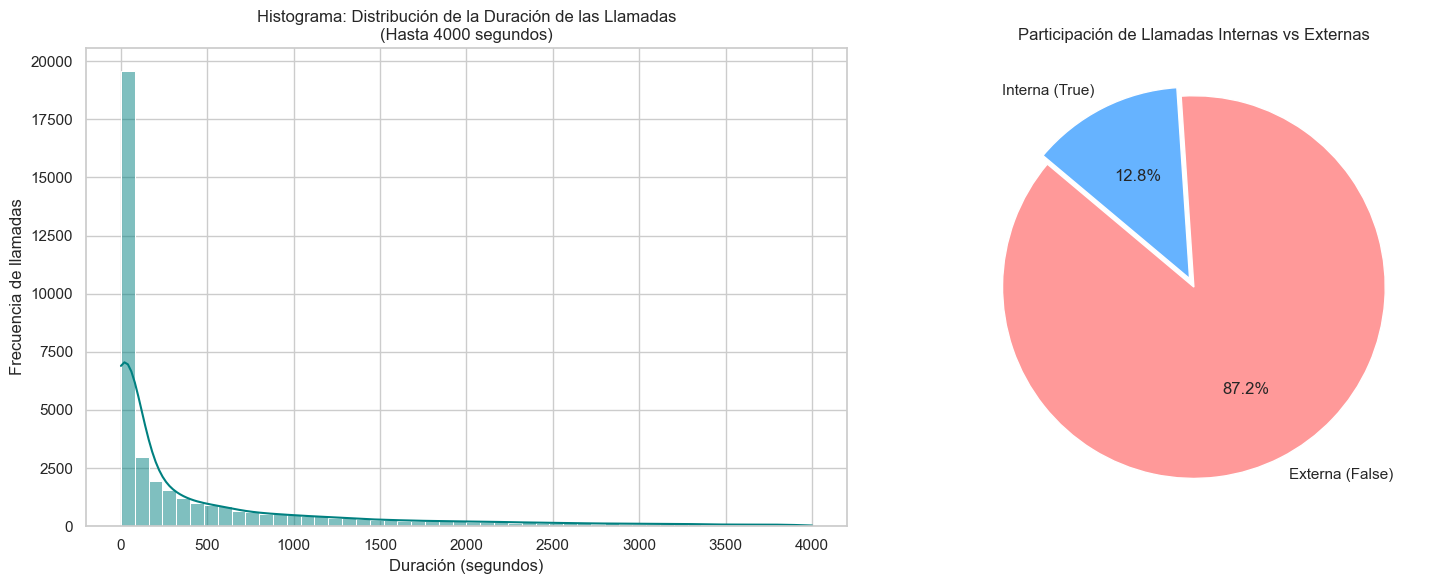

--- DISTRIBUCIÓN POR DIRECCIÓN (FILTRO IN/OUT) ---


direction,in,out
internal,,
False,93111,595369
True,691,12974


In [91]:
# Configurar una cuadrícula de 1 fila y 2 columnas para los gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histograma para la duración de la llamada (Filtrando valores extremos para mejor visibilidad)
sns.histplot(
    data=df_telecom[df_telecom['call_duration'] <= 4000], 
    x='call_duration', 
    bins=50, 
    kde=True, 
    color='teal', 
    ax=axes[0]
)
axes[0].set_title('Histograma: Distribución de la Duración de las Llamadas\n(Hasta 4000 segundos)', fontsize=12)
axes[0].set_xlabel('Duración (segundos)')
axes[0].set_ylabel('Frecuencia de llamadas')

# Preparar datos para el gráfico circular (Distribución de llamadas Internas vs Externas)
llamadas_internas = df_telecom['internal'].value_counts()
labels_pie = ['Externa (False)', 'Interna (True)']
colors_pie = ['#ff9999', '#66b3ff']

# Gráfico circular de llamadas internas y externas
axes[1].pie(
    llamadas_internas, 
    labels=labels_pie, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_pie,
    explode=(0, 0.05)
)
axes[1].set_title('Participación de Llamadas Internas vs Externas', fontsize=12)

plt.tight_layout()
plt.show()

# Resumen de soporte para el filtro solicitado (Métricas cruzadas por Dirección)
print("--- DISTRIBUCIÓN POR DIRECCIÓN (FILTRO IN/OUT) ---")
display(pd.crosstab(df_telecom['internal'], df_telecom['direction'], values=df_telecom['calls_count'], aggfunc='sum'))


Podemos observar que el 87.2% de la operación corresponde a llamadas externas. Esto significa que los operadores interactúan de forma casi total con clientes fuera de la red.
En la tabla de contingencia, demuestra que las llamadas salientes (out / False) dominan drasticamente el flujo con 595,369 llamadas.

### Conclusiones

* Se encuentra un alto índice de ineficacia, dado que el 42.58% de los operadores (465 de 1092) cumplen con al menos un criterio de ineficacia operativa. Lo que representa un riesgo crítico para la retención de clientes de la plataforma CallMeMaybe.
* La prueba de Mann-Whitney U confirmó que los operadores catalogados como ineficaces degradan la experiencia del usuario de forma sistemática. Generan tiempos de espera que superan el percentil 75 global (más de 17.5 segundos por llamada).
* La prueba de Chi-cuadrado demostró que la ineficacia no se distribuye al azar. El Plan Tarifario A presenta una proporción alarmante de operadores ineficaces en comparación con el Plan C. Esto sugiere que las cuentas de dicha tarifa podrían estar sufriendo un déficit de atención o una sobrecarga de tráfico.
*  El 87.2% del volumen total de la plataforma corresponde a interacciones externas. Por lo que la ineficacia esta impactando directamente la reputación de las empresas clientes frente al mercado exterior, no a comunicaciones internas.

### Recomendaciones
* Configurar en la función de telefonía virtual un sistema de banderas, en que éste notifique automáticamente a los supervisores cuando un operador acumule un tiempo de espera promedio superior a los 17.5 segundos.
* Considerar un programa de entrenamiento enfocados en la resolución ágil de llamadas entrantes para reducir el cuello de botella del tiempo en espera. Para los operadores con perfil out, fijar cuotas mínimas superiores a 5 llamadas diarias para mitigar la inactividad.

### Fuentes Técnicas Utilizadas

1. **Pandas Documentation (`pandas.DataFrame.groupby`)**: Utilizada para entender la agregación de datos multifactorial por operador y aplicar funciones lambda personalizadas en el análisis de llamadas entrantes y salientes.
2. **Seaborn Statistical Data Visualization (`seaborn.histplot`)**: Consultada para configurar los parámetros de visualización y ajustar los contenedores (`bins`) idóneos en la distribución asimétrica del tiempo de espera y duración de llamadas.
3. **Scipy Stats Module (`scipy.stats.mannwhitneyu`)**: Utilizada para seleccionar la prueba no paramétrica adecuada para comparar las medianas de tiempo de espera, debido al alto sesgo y presencia de outliers en los datos.
4. **Scipy Stats Contingency (`scipy.stats.chi2_contingency`)**: Consultada para estructurar correctamente la tabla de contingencia de frecuencias observadas y validar la dependencia estadística entre planes tarifarios y el desempeño.
5. **Matplotlib Pyplot API (`matplotlib.pyplot.subplots`)**: Utilizada como referencia para gestionar la arquitectura de cuadrículas y renderizar múltiples gráficos independientes dentro de una misma figura de visualización.
